# EQDuration_Macaulay - Geführtes Notebook

Dieses Notebook konstruiert die **Macaulay DCF Duration auf EPS-Basis** für das EURO500-Universum.

Ziel:
- saubere Trennung zwischen **explizitem Forecast-Horizont** und **Terminalstruktur**
- transparente Formel-zu-Code-Abbildung
- nachvollziehbare Interpretation der resultierenden Duration

3 Wesentliche Schritte
1. Expliziter Forecast-Horizont (FY1-FYH)
2. Two-Stage Terminal Structure (Fade + Perpetuity)
3. Aggregation zur Macaulay Duration


## 1) Setup und Modellparameter

In diesem Block definiere ich den Datenpfad und die ökonomischen Konstanten.

Fixe Modellannahmen:
- Diskontsatz: $R = 10\%$
- Maximaler expliziter Horizont: $T=5$
- Cap für firmenspezifisches LTG: $g_i = \min(LTG_i, 5\%)$
- Langfristiges Wachstum: $g_\infty = 2\%$
- Fade-Länge: 10 Jahre

Wichtig: Für die Perpetuity muss stets gelten $R > g_\infty$.


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd

BASE_DIR = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data')
DATA_DIR = BASE_DIR / 'intermediate'

R = 0.10
T = 5
G_CAP = 0.05
G_INF = 0.02
FADE_YEARS = 10

if R <= max(G_CAP, G_INF):
    raise ValueError(f'Need R > max(g_cap, g_inf). Got R={R}, g_cap={G_CAP}, g_inf={G_INF}')

print('Data dir:', DATA_DIR)
print('Parameters:', {'T': T, 'R': R, 'g_cap': G_CAP, 'g_inf': G_INF, 'fade_years': FADE_YEARS})


Data dir: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate
Parameters: {'T': 5, 'R': 0.1, 'g_cap': 0.05, 'g_inf': 0.02, 'fade_years': 10}


## 2) Input laden und verwendete Forecast-Spalten bestimmen

Ich lade die EPS-Tabelle und bestimme robust, welche Forward-Spalten verfügbar sind.

Regel:
- mind. 3 verfügbare Forecast-Jahre pro Zeile notwendig
- Ziel ist FY1-FY5; falls weniger vorhanden, wird zeilenweise ein kürzerer Horizont genutzt


In [22]:
candidate_files = [
    'euro500_EPS.parquet',
]

selected_path = None
for name in candidate_files:
    candidate = DATA_DIR / name
    if candidate.exists():
        selected_path = candidate
        break

if selected_path is None:
    raise FileNotFoundError('Keine passende Input-Tabelle gefunden (erwartet: euro500_EPS.parquet).')

df = pd.read_parquet(selected_path).copy()
print('Loaded:', selected_path)
print('Shape:', df.shape)
print('Columns (first 30):', list(df.columns)[:30])


Loaded: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_EPS.parquet
Shape: (54000, 35)
Columns (first 30): ['date', 'formation_date', 'effective_date', 'quarter', 'RIC', 'name', 'firm_id', 'hq_country', 'hq_code', 'trbc_sector', 'trbc_sector_code', 'mcap_eur', 'RIC_current', 'ISIN', 'SEDOL', 'first_trade_date', 'ipo_date', 'FreeFloat', 'FreeFloatPct', 'Volume', 'PriceClose', 'InstrumentType', 'Currency', 'rank_mcap', 'asof_date', 'beta_3m', 'id_type', 'pull_id', 'company_key', 'beta']


In [23]:
cashflow_priority = [
    ['EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5'],
]

cf_cols = None
for cand in cashflow_priority:
    available = [c for c in cand if c in df.columns]
    if len(available) >= 3:
        cf_cols = available[:T]
        break

if cf_cols is None:
    raise KeyError('No suitable cashflow columns found. Need at least FY1..FY3.')

id_candidates = ['RIC', 'firm_id', 'name', 'date', 'asof_date', 'quarter', 'year']
id_cols = [c for c in id_candidates if c in df.columns]

print('Using cashflow columns:', cf_cols)
print('ID columns used:', id_cols)


Using cashflow columns: ['EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5']
ID columns used: ['RIC', 'firm_id', 'name', 'date', 'asof_date', 'quarter']


## 3) Expliziter Forecast-Horizont

**Theorie (FY1-FYH):**

Für $s=1,\dots,H_i$ gilt:
$$
PV_{i,t+s} = \frac{EPS_{i,t+s}}{(1+R)^s}
$$

Dann:
$$
PV_F = \sum_{s=1}^{H_i} PV_{i,t+s}, \qquad
N_F = \sum_{s=1}^{H_i} s\cdot PV_{i,t+s}
$$

Dabei ist $H_i$ die Anzahl verfügbarer Forecasts pro Firma (maximal 5, minimal 3 für valide Beobachtungen).


In [24]:
work = df.copy()
for ccol in cf_cols:
    work[ccol] = pd.to_numeric(work[ccol], errors='coerce').astype('float64')

if 'LTGMean' not in work.columns:
    work['LTGMean'] = np.nan

work['LTGMean'] = pd.to_numeric(work['LTGMean'], errors='coerce').astype('float64')
work['LTGMean_dec'] = work['LTGMean'] / 100.0
work['g_used'] = np.minimum(work['LTGMean_dec'], G_CAP)
work['g_used'] = work['g_used'].fillna(G_INF).astype('float64')

work['H_used'] = work[cf_cols].notna().sum(axis=1).astype(int)
work.loc[work['H_used'] > T, 'H_used'] = T

print('H_used distribution:')
print(work['H_used'].value_counts(dropna=False).sort_index())




H_used distribution:
H_used
0     5686
5    48314
Name: count, dtype: int64


In [25]:
work['PV_F'] = 0.0
work['Duration_num_F'] = 0.0

for s, ccol in enumerate(cf_cols, start=1):
    pv_s = work[ccol] / ((1 + R) ** s)
    work['PV_F'] += pv_s.fillna(0.0)
    work['Duration_num_F'] += s * pv_s.fillna(0.0)

work[['PV_F', 'Duration_num_F']].describe()


,PV_F,Duration_num_F
count,5.400000e+04,5.400000e+04
mean,4.326572e+02,1.215821e+03
std,1.638440e+04,4.604223e+04
min,-4.540909e+05,-1.276053e+06
25%,1.165468e+00,3.275112e+00
50%,4.245681e+00,1.193090e+01
75%,1.023526e+01,2.876236e+01
max,1.122723e+06,3.154994e+06


## 4) Two-Stage Terminal Structure

Ausgangspunkt ist der letzte verfügbare Forecast-Cashflow je Firma, also $EPS_{t+H_i}$.

### Stage A: Fade-Phase (10 Jahre)
- Wachstum fällt linear von firmenspezifischem $g_i$ auf $g_\infty=2\%$.
- Alle Stage-A-Cashflows werden korrekt auf $t$ diskontiert (Zeitpunkt $H_i + k$).

### Stage B: Perpetuity
Nach der Fade-Phase wird ein Gordon-Terminalwert angesetzt:
$$
TV_{H_i+N} = \frac{CF_N(1+g_\infty)}{R-g_\infty}
$$
Dieser wird auf $t$ diskontiert und auch im Zähler zeitgewichtet berücksichtigt.


In [26]:
last_cf = pd.Series(np.nan, index=work.index, dtype='float64')
for s, ccol in enumerate(cf_cols, start=1):
    mask = work['H_used'].eq(s)
    last_cf.loc[mask] = work.loc[mask, ccol]

last_cf.describe()


count     48314.000000
mean        127.566108
std        4569.242569
min     -119788.044000
25%           0.527722
50%           1.338875
75%           3.019928
max      296171.627140
dtype: float64

In [27]:
pv_stageA_t0 = pd.Series(0.0, index=work.index, dtype='float64')
num_stageA_t0 = pd.Series(0.0, index=work.index, dtype='float64')

cf_prev = last_cf.copy()
cf_N = pd.Series(np.nan, index=work.index, dtype='float64')

for k in range(1, FADE_YEARS + 1):
    w = k / FADE_YEARS
    gk = work['g_used'] + (G_INF - work['g_used']) * w
    cf_k = cf_prev * (1 + gk)

    pv_k = pd.Series(np.nan, index=work.index, dtype='float64')
    for h in sorted(work['H_used'].dropna().unique()):
        if h <= 0:
            continue
        mask = work['H_used'].eq(int(h))
        pv_k.loc[mask] = cf_k.loc[mask] / ((1 + R) ** (int(h) + k))

    pv_stageA_t0 += pv_k.fillna(0.0)

    for h in sorted(work['H_used'].dropna().unique()):
        if h <= 0:
            continue
        mask = work['H_used'].eq(int(h))
        num_stageA_t0.loc[mask] += (int(h) + k) * pv_k.loc[mask].fillna(0.0)

    cf_prev = cf_k
    cf_N = cf_k

pd.DataFrame({'PV_TV_fade': pv_stageA_t0, 'Num_TV_fade': num_stageA_t0}).describe()


,PV_TV_fade,Num_TV_fade
count,5.400000e+04,5.400000e+04
mean,4.789140e+02,4.733089e+03
std,1.813611e+04,1.792385e+05
min,-5.026394e+05,-4.967565e+06
25%,1.290072e+00,1.274973e+01
50%,4.699602e+00,4.644598e+01
75%,1.132954e+01,1.119694e+02
max,1.242758e+06,1.228213e+07


In [28]:
tv_perp_at_HN = cf_N * (1 + G_INF) / (R - G_INF)
pv_perp_t0 = pd.Series(np.nan, index=work.index, dtype='float64')
num_perp_t0 = pd.Series(np.nan, index=work.index, dtype='float64')

for h in sorted(work['H_used'].dropna().unique()):
    if h <= 0:
        continue
    mask = work['H_used'].eq(int(h))
    pv_perp_t0.loc[mask] = tv_perp_at_HN.loc[mask] / ((1 + R) ** (int(h) + FADE_YEARS))

    # Effektive Timing-Regel für den perpetuity-Block in der Macaulay-Gewichtung
    t_eff = int(h) + FADE_YEARS + (1 + R) / (R - G_INF)
    num_perp_t0.loc[mask] = t_eff * pv_perp_t0.loc[mask]

pd.DataFrame({'PV_TV_perp': pv_perp_t0, 'Num_TV_perp': num_perp_t0}).describe()


,PV_TV_perp,Num_TV_perp
count,4.831400e+04,4.831400e+04
mean,4.746319e+02,1.364567e+04
std,1.700066e+04,4.887690e+05
min,-4.456923e+05,-1.281365e+07
25%,1.963483e+00,5.645015e+01
50%,4.981517e+00,1.432186e+02
75%,1.123617e+01,3.230398e+02
max,1.101958e+06,3.168129e+07


## 5) Aggregation zur Macaulay Duration

Nun werden alle Komponenten zusammengeführt:

$$
P^{DCF} = PV_F + PV_{TV}
$$

$$
D^{Macaulay}_{i,t} = \frac{N_F + N_{TV}}{P^{DCF}}
$$

Interpretation:
- Die Duration ist der **present-value-gewichtete durchschnittliche Zeitpunkt** der erwarteten Earnings.
- Hohe Duration bedeutet: Ein größerer Anteil des Unternehmenswerts liegt in weiter entfernten Zahlungszeitpunkten.


In [29]:
work['PV_TV_fade'] = pv_stageA_t0
work['PV_TV_perp'] = pv_perp_t0
work['PV_TV'] = work['PV_TV_fade'] + work['PV_TV_perp']
work['P_DCF'] = work['PV_F'] + work['PV_TV']

work['Duration_num_TV'] = num_stageA_t0 + num_perp_t0
work['Duration_num'] = work['Duration_num_F'] + work['Duration_num_TV']

work['Terminal_weight'] = np.where(
    work['P_DCF'].notna() & (work['P_DCF'] != 0),
    work['PV_TV'] / work['P_DCF'],
    np.nan,
)

valid = (
    work['P_DCF'].notna()
    & (work['P_DCF'] > 0)
    & (work['H_used'] >= 3)
    & work['g_used'].notna()
    & (work['g_used'] < R)
)

work['Duration_DCF_Macaulay'] = np.nan
work.loc[valid, 'Duration_DCF_Macaulay'] = (
    work.loc[valid, 'Duration_num'] / work.loc[valid, 'P_DCF']
)
work['status'] = np.where(valid, 'ok', 'invalid_P_DCF_nonpositive_or_missing')

res_cols = id_cols + cf_cols + [
    'LTGMean', 'LTGMean_dec', 'g_used', 'H_used',
    'PV_F', 'PV_TV_fade', 'PV_TV_perp', 'PV_TV', 'P_DCF', 'Terminal_weight',
    'Duration_num', 'Duration_DCF_Macaulay', 'status'
]
result = work[res_cols].copy()

print(result['status'].value_counts(dropna=False))
print('Valid share:', float((result['status'] == 'ok').mean()))
result.head(10)


status
ok                                      46343
invalid_P_DCF_nonpositive_or_missing     7657
Name: count, dtype: int64
Valid share: 0.8582037037037037


,RIC,firm_id,name,date,asof_date,quarter,EPS_FY1,EPS_FY2,EPS_FY3,EPS_FY4,...,H_used,PV_F,PV_TV_fade,PV_TV_perp,PV_TV,P_DCF,Terminal_weight,Duration_num,Duration_DCF_Macaulay,status
0,DTEGn.DE,FIRM0000557,Deutsche Telekom AG,1998-12-31,1999-03-31,1999Q1,0.78345,0.78345,0.78345,0.78345,...,5,2.969892,3.287413,2.914962,6.202375,9.172267,0.67621,124.640308,13.588822,ok
1,ALVG.DE,FIRM0002478,Allianz SE,1998-12-31,1999-03-31,1999Q1,6.65750,6.65750,6.65750,6.65750,...,5,25.237163,27.935355,24.770387,52.705742,77.942905,0.67621,1059.152274,13.588822,ok
2,FTE.PA,FIRM0000208,Orange SA,1998-12-31,1999-03-31,1999Q1,2.06905,2.06905,2.06905,2.06905,...,5,7.843327,8.681884,7.698261,16.380145,24.223472,0.67621,329.168459,13.588822,ok
3,AEGN.AS,FIRM0002474,Aegon Ltd,1998-12-31,1999-03-31,1999Q1,1.19810,1.19810,1.19810,1.19810,...,5,4.541742,5.027315,4.457740,9.485054,14.026796,0.67621,190.607637,13.588822,ok
4,OLIV.MI,FIRM0000351,Telecom Italia SpA,1998-12-31,1999-03-31,1999Q1,-0.01406,-0.01406,-0.01406,-0.01406,...,5,-0.053298,-0.058997,-0.052313,-0.111309,-0.164608,0.67621,-2.236828,NaN,invalid_P_DCF_nonpositive_or_missing
5,BBVA.MC,FIRM0002482,Banco Bilbao Vizcaya Argentaria SA,1998-12-31,1999-03-31,1999Q1,0.45011,0.45011,0.45011,0.45011,...,5,1.706271,1.888694,1.674713,3.563407,5.269678,0.67621,71.608717,13.588822,ok
6,INGA.AS,FIRM0002512,ING Groep NV,1998-12-31,1999-03-31,1999Q1,1.14433,1.14433,1.14433,1.14433,...,5,4.337911,4.801692,4.257679,9.059371,13.397282,0.67621,182.053282,13.588822,ok
7,ENI.MI,FIRM0000171,Eni SpA,1998-12-31,1999-03-31,1999Q1,0.64441,0.64441,0.64441,0.64441,...,5,2.442821,2.703991,2.397640,5.101631,7.544452,0.67621,102.520213,13.588822,ok
8,DCXGn.DE,FIRM0000137,Mercedes-Benz Group AG,1998-12-31,1999-03-31,1999Q1,6.55067,6.55067,6.55067,6.55067,...,5,24.832193,27.487088,24.372908,51.859996,76.692189,0.67621,1042.156520,13.588822,ok
9,AXAF.PA,FIRM0002481,AXA SA,1998-12-31,1999-03-31,1999Q1,1.18133,1.18133,1.18133,1.18133,...,5,4.478170,4.956947,4.395344,9.352291,13.830461,0.67621,187.939671,13.588822,ok


## 6) Plausibilitätscheck

Ich prüfe zentrale Größen nur auf validen Beobachtungen (`status == 'ok'`).


In [30]:
ok = result[result['status'] == 'ok'].copy()
if len(ok) == 0:
    print('No valid rows found.')
else:
    print(ok['Duration_DCF_Macaulay'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
    if 'year' in ok.columns:
        print('Rows per year (head):')
        print(ok.groupby('year').size().head(10))


count    4.634300e+04
mean     1.358882e+01
std      2.506450e-15
min      1.358882e+01
1%       1.358882e+01
5%       1.358882e+01
50%      1.358882e+01
95%      1.358882e+01
99%      1.358882e+01
max      1.358882e+01
Name: Duration_DCF_Macaulay, dtype: float64


## 7) Speichern des finalen Outputs

Der berechnete Panel-Output wird als Parquet gespeichert und in weiteren Notebooks weiterverwendet.


In [31]:
out_path = DATA_DIR / 'EQDuration_Macaulay.parquet'
result.to_parquet(out_path, index=False)
print('Saved:', out_path)

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Macaulay.parquet


## 8) Analyse: Datenqualität und Verteilung

Diese Sektion zeigt:
- Anteil valider Beobachtungen
- Verteilung der Duration (raw und winsorized)
- Verteilung des Terminalgewichts
- Querschnittliche Streuung über Quartale


,metric,value
0,rows_total,54000.000000
1,rows_ok,46343.000000
2,rows_invalid,7657.000000
3,ok_share,0.858204
4,share_missing_any_CF,0.105296
5,share_nonpositive_P_DCF,0.036500


Duration describe (ok only):


count    4.634300e+04
mean     1.358882e+01
std      2.506450e-15
min      1.358882e+01
1%       1.358882e+01
5%       1.358882e+01
25%      1.358882e+01
50%      1.358882e+01
75%      1.358882e+01
95%      1.358882e+01
99%      1.358882e+01
max      1.358882e+01
Name: Duration_DCF_Macaulay, dtype: float64

Winsorized 1%-99% describe (ok only):


count    4.634300e+04
mean     1.358882e+01
std      2.486745e-15
min      1.358882e+01
1%       1.358882e+01
5%       1.358882e+01
25%      1.358882e+01
50%      1.358882e+01
75%      1.358882e+01
95%      1.358882e+01
99%      1.358882e+01
max      1.358882e+01
Name: Duration_DCF_Macaulay, dtype: float64

Terminal_weight describe (ok only):


count    4.634300e+04
mean     6.762096e-01
std      9.805257e-17
min      6.762096e-01
1%       6.762096e-01
5%       6.762096e-01
25%      6.762096e-01
50%      6.762096e-01
75%      6.762096e-01
95%      6.762096e-01
99%      6.762096e-01
max      6.762096e-01
Name: Terminal_weight, dtype: float64

Terminal_weight winsorized 1%-99% describe:


count    4.634300e+04
mean     6.762096e-01
std      9.794129e-17
min      6.762096e-01
1%       6.762096e-01
5%       6.762096e-01
25%      6.762096e-01
50%      6.762096e-01
75%      6.762096e-01
95%      6.762096e-01
99%      6.762096e-01
max      6.762096e-01
Name: Terminal_weight, dtype: float64

ValueError: Too many bins for data range. Cannot create 80 finite-sized bins.

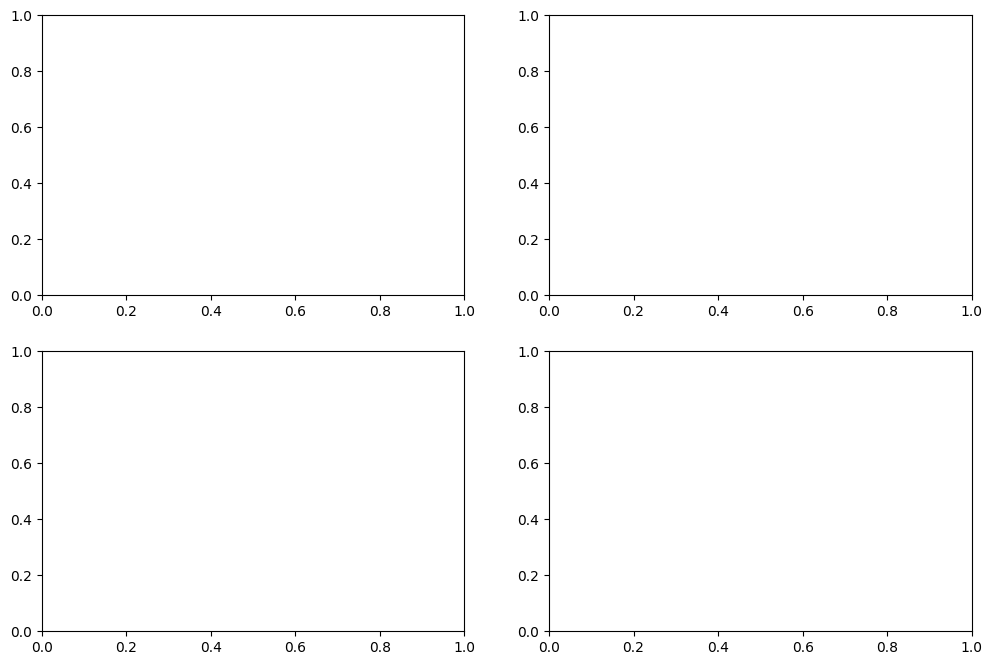

In [32]:
import matplotlib.pyplot as plt

ana = result.copy()
ana['is_ok'] = ana['status'].eq('ok')
n_total = len(ana)
n_ok = int(ana['is_ok'].sum())
n_bad = n_total - n_ok
cf_missing = ana[cf_cols].isna().any(axis=1)
pdcf_nonpos = ana['P_DCF'].notna() & (ana['P_DCF'] <= 0)

quality = pd.DataFrame({
    'metric': [
        'rows_total',
        'rows_ok',
        'rows_invalid',
        'ok_share',
        'share_missing_any_CF',
        'share_nonpositive_P_DCF'
    ],
    'value': [
        n_total,
        n_ok,
        n_bad,
        n_ok / n_total if n_total else np.nan,
        float(cf_missing.mean()),
        float(pdcf_nonpos.mean())
    ]
})

display(quality)

d_ok = ana.loc[ana['is_ok'], 'Duration_DCF_Macaulay'].dropna()
print('Duration describe (ok only):')
display(d_ok.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

d_w = d_ok.clip(lower=d_ok.quantile(0.01), upper=d_ok.quantile(0.99))
print('Winsorized 1%-99% describe (ok only):')
display(d_w.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

tw_ok = ana.loc[ana['is_ok'], 'Terminal_weight'].dropna()
print('Terminal_weight describe (ok only):')
display(tw_ok.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

tw_w = tw_ok.clip(lower=tw_ok.quantile(0.01), upper=tw_ok.quantile(0.99))
print('Terminal_weight winsorized 1%-99% describe:')
display(tw_w.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].hist(d_ok, bins=80)
ax[0, 0].set_title('Duration_DCF_Macaulay (raw)')
ax[0, 0].set_xlabel('Duration')

ax[0, 1].hist(d_w, bins=80)
ax[0, 1].set_title('Duration_DCF_Macaulay (winsor 1%-99%)')
ax[0, 1].set_xlabel('Duration')

ax[1, 0].hist(tw_ok, bins=80)
ax[1, 0].set_title('Terminal_weight (raw)')
ax[1, 0].set_xlabel('PV_TV / P_DCF')

ax[1, 1].hist(tw_w, bins=80)
ax[1, 1].set_title('Terminal_weight (winsor 1%-99%)')
ax[1, 1].set_xlabel('PV_TV / P_DCF')

plt.tight_layout()
plt.show()

if 'quarter' in ana.columns:
    cs_std_desc = (
        ana.loc[ana['is_ok']]
        .groupby('quarter')['Duration_DCF_Macaulay']
        .std()
        .describe()
    )
    print('Cross-sectional std per quarter:')
    display(cs_std_desc)


## 9) Analyse: Zeit- und Sektorstabilität

Hier prüfe ich, ob sich die Duration über Jahre sowie sektoral plausibel unterscheidet.


,year,n,p10,median,p90,mean


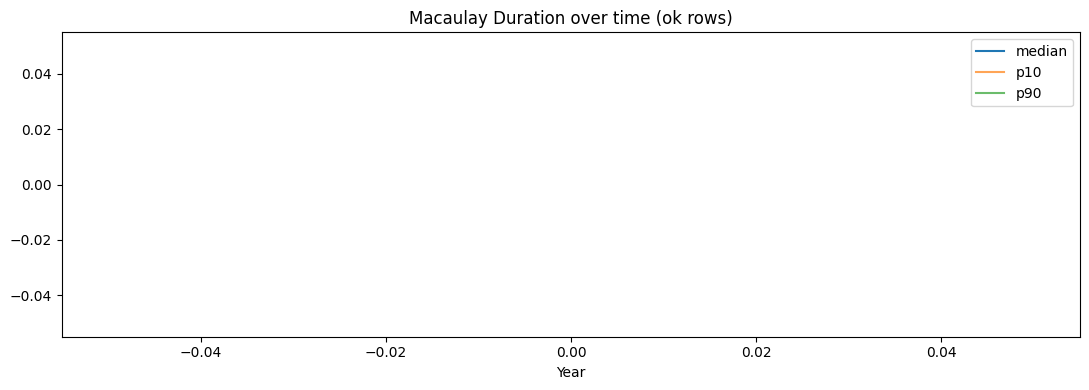

Sector stability skipped: required columns or file missing.


In [ ]:
ana = result.copy()

if 'asof_date' in ana.columns:
    ana['year'] = pd.to_datetime(ana['asof_date']).dt.year
elif 'date' in ana.columns:
    ana['year'] = pd.to_datetime(ana['date']).dt.year
else:
    ana['year'] = np.nan

ok = ana[ana['status'].eq('ok')].copy()

year_stats = ok.groupby('year')['Duration_DCF_Macaulay'].agg(
    n='count',
    p10=lambda x: x.quantile(0.10),
    median='median',
    p90=lambda x: x.quantile(0.90),
    mean='mean'
).reset_index()

display(year_stats.head(20))

fig, ax = plt.subplots(1, 1, figsize=(11, 4))
ax.plot(year_stats['year'], year_stats['median'], label='median')
ax.plot(year_stats['year'], year_stats['p10'], label='p10', alpha=0.7)
ax.plot(year_stats['year'], year_stats['p90'], label='p90', alpha=0.7)
ax.set_title('Macaulay Duration over time (ok rows)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

sec_path = DATA_DIR / 'euro500_x_EPS.parquet'
if sec_path.exists() and all(c in ok.columns for c in ['RIC', 'quarter', 'asof_date']):
    sec = pd.read_parquet(sec_path)[['RIC', 'quarter', 'asof_date', 'trbc_sector']].copy()
    sec['asof_date'] = pd.to_datetime(sec['asof_date'])
    ok['asof_date'] = pd.to_datetime(ok['asof_date'])

    ok_sec = ok.merge(
        sec.drop_duplicates(['RIC', 'quarter', 'asof_date']),
        on=['RIC', 'quarter', 'asof_date'],
        how='left'
    )
    sec_stats = (
        ok_sec.groupby('trbc_sector')['Duration_DCF_Macaulay']
        .agg(n='count', median='median', mean='mean')
        .sort_values('median', ascending=False)
    )
    display(sec_stats.head(15))
else:
    print('Sector stability skipped: required columns or file missing.')


## 10) Analyse: Einfacher Zins-Shock-Test (Long HighD - Short LowD)

Idee:
- bilde je Quartal Duration-Quintile
- konstruiere Long-Short-Rendite $Q5-Q1$
- regressiere auf tägliche Änderung des 2Y OIS (`dy`)

Interpretation:
- ein negativer `dy`-Koeffizient ist konsistent mit höherer Zinssensitivität von High-Duration-Aktien.


In [ ]:
rets_path = DATA_DIR / 'daily_returns_euro500_in_index.parquet'
ois_path = DATA_DIR / 'rates_2yOIS_daily.parquet'

if not (rets_path.exists() and ois_path.exists()):
    print('Missing required files for shock test.')
else:
    dur_q = result[result['status'].eq('ok')][['RIC', 'quarter', 'Duration_DCF_Macaulay']].copy()
    dur_q = dur_q.dropna().drop_duplicates(['RIC', 'quarter'])

    dur_q['q'] = dur_q.groupby('quarter')['Duration_DCF_Macaulay'].transform(
        lambda s: pd.qcut(s.rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
    )

    rets = pd.read_parquet(rets_path)[['date', 'quarter', 'RIC', 'ret']].copy()
    rets['date'] = pd.to_datetime(rets['date'])
    rets['ret'] = pd.to_numeric(rets['ret'], errors='coerce')

    px = rets.merge(dur_q[['RIC', 'quarter', 'q']], on=['RIC', 'quarter'], how='inner')
    px = px.dropna(subset=['ret', 'q'])

    q_daily = px.groupby(['date', 'q'])['ret'].mean().reset_index()
    q_wide = q_daily.pivot(index='date', columns='q', values='ret')
    q_wide['LS_5m1'] = q_wide[5] - q_wide[1]

    ois = pd.read_parquet(ois_path).copy()
    ois['date'] = pd.to_datetime(ois['date'])
    ois['dy'] = pd.to_numeric(ois['dy'], errors='coerce')

    reg = q_wide[['LS_5m1']].merge(
        ois[['date', 'dy']].set_index('date'),
        left_index=True,
        right_index=True,
        how='inner'
    ).dropna()

    y = reg['LS_5m1'].to_numpy()
    x = reg['dy'].to_numpy()
    X = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    yhat = X @ beta
    resid = y - yhat
    n = len(y)
    k = X.shape[1]
    s2 = (resid @ resid) / max(n - k, 1)
    vcov = s2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(vcov))
    tvals = beta / se

    out = pd.DataFrame(
        {'coef': beta, 'std_err': se, 't_value': tvals},
        index=['const', 'dy']
    )

    print('Regression: LS_5m1 ~ const + dy')
    print('n_obs:', n)
    display(out)
    print('Average LS_5m1 daily return:', reg['LS_5m1'].mean())


Missing required files for shock test.


## 11) Fazit und Lesart der Duration

Wenn `Duration_DCF_Macaulay` steigt, verschiebt sich der wertrelevante Teil der Earnings zeitlich nach hinten.

Ökonomisch heißt das:
- höhere Abhängigkeit vom Terminalanteil
- stärkere Exponierung gegenüber Änderungen in Zinsen und langfristigen Erwartungen
- bei konstantem Diskontsatz wird primär ein **Timing-Effekt** gemessen
